In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf

print("Версия TensorFlow:", tf.__version__)
print("Доступные GPU:", tf.config.list_physical_devices('GPU'))
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[0], 'GPU')

Версия TensorFlow: 2.21.0
Доступные GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger,
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, accuracy_score

In [33]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTO = tf.data.AUTOTUNE

DATA_DIR = Path("/home/sm/Desktop/ml/CarBrandClassificationDataset")

EPOCHS_WARMUP = 12
EPOCHS_FINETUNE = 24

AUTO = tf.data.AUTOTUNE

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

## 1. Загрузка структуры датасета

Ожидается структура:

```text
CarBrandClassificationDataset/
├── train/
│   ├── class_1/
│   └── ...
├── val/
│   ├── class_1/
│   └── ...
└── test/
    ├── class_1/
    └── ...
```

В таблицы ниже собираются пути к изображениям и строковые метки классов.

In [14]:
train_base = DATA_DIR / "train"
val_base = DATA_DIR / "val"
test_base = DATA_DIR / "test"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def build_split_df(split_dir: Path) -> pd.DataFrame:
    """Собирает таблицу path/label для одного split'а."""
    if not split_dir.exists():
        raise FileNotFoundError(f"Папка split'а не найдена: {split_dir}")

    rows = []
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    for cls_dir in class_dirs:
        cls = cls_dir.name
        for f in cls_dir.rglob("*"):
            if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append((str(f), cls))
    return pd.DataFrame(rows, columns=["path", "label"])

df_train = build_split_df(train_base)
df_val = build_split_df(val_base)
df_test = build_split_df(test_base)

print("Количество изображений:")
print("Train:", len(df_train), "| классов:", df_train["label"].nunique())
print("Val  :", len(df_val), "| классов:", df_val["label"].nunique())
print("Test :", len(df_test), "| классов:", df_test["label"].nunique())

display(pd.concat({
    "train": df_train["label"].value_counts().sort_index(),
    "val": df_val["label"].value_counts().sort_index(),
    "test": df_test["label"].value_counts().sort_index(),
}, axis=1).fillna(0).astype(int).head())

Количество изображений:
Train: 11517 | классов: 33
Val  : 2475 | классов: 33
Test : 2475 | классов: 33


,train,val,test
label,,,
Acura,349,75,75
Aston Martin,349,75,75
Audi,349,75,75
BMW,349,75,75
Bentley,349,75,75


In [15]:
# Единое отображение классов в индексы.
classes = sorted(df_train["label"].unique().tolist())
class2idx = {c: i for i, c in enumerate(classes)}
idx2class = {i: c for c, i in class2idx.items()}
num_classes = len(classes)

for name, df in [("val", df_val), ("test", df_test)]:
    missing = set(df["label"].unique()) - set(classes)
    if missing:
        raise ValueError(f"В {name} есть классы, которых нет в train: {sorted(missing)}")

df_train["label_idx"] = df_train["label"].map(class2idx)
df_val["label_idx"] = df_val["label"].map(class2idx)
df_test["label_idx"] = df_test["label"].map(class2idx)

print("Число классов:", num_classes)
print("Пример отображения:", list(class2idx.items())[:10])
df_train.head()

Число классов: 33
Пример отображения: [('Acura', 0), ('Aston Martin', 1), ('Audi', 2), ('BMW', 3), ('Bentley', 4), ('Buick', 5), ('Cadillac', 6), ('Chevrolet', 7), ('Chrysler', 8), ('Dodge', 9)]


,path,label,label_idx
0,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
1,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
2,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
3,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
4,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0


## 2. Распределение изображений по классам

равномерное распределение по всем классам

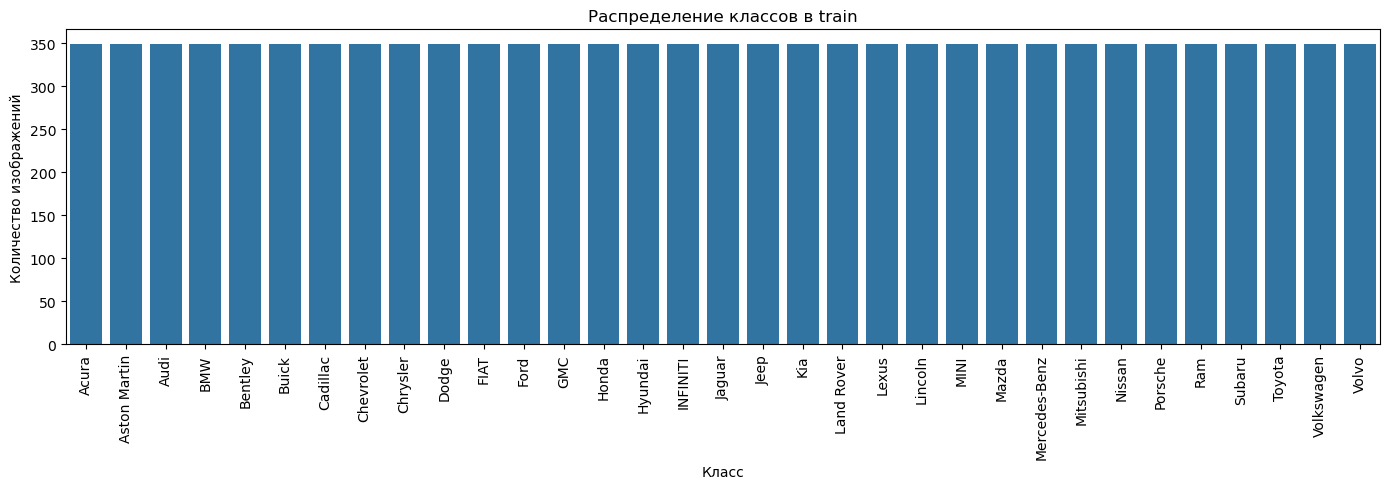

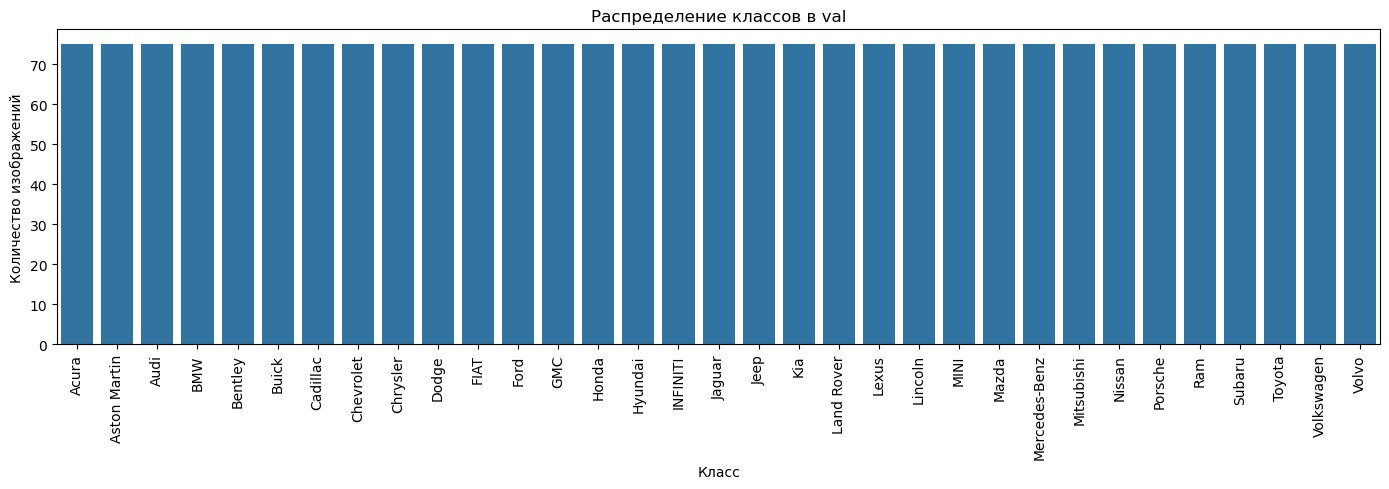

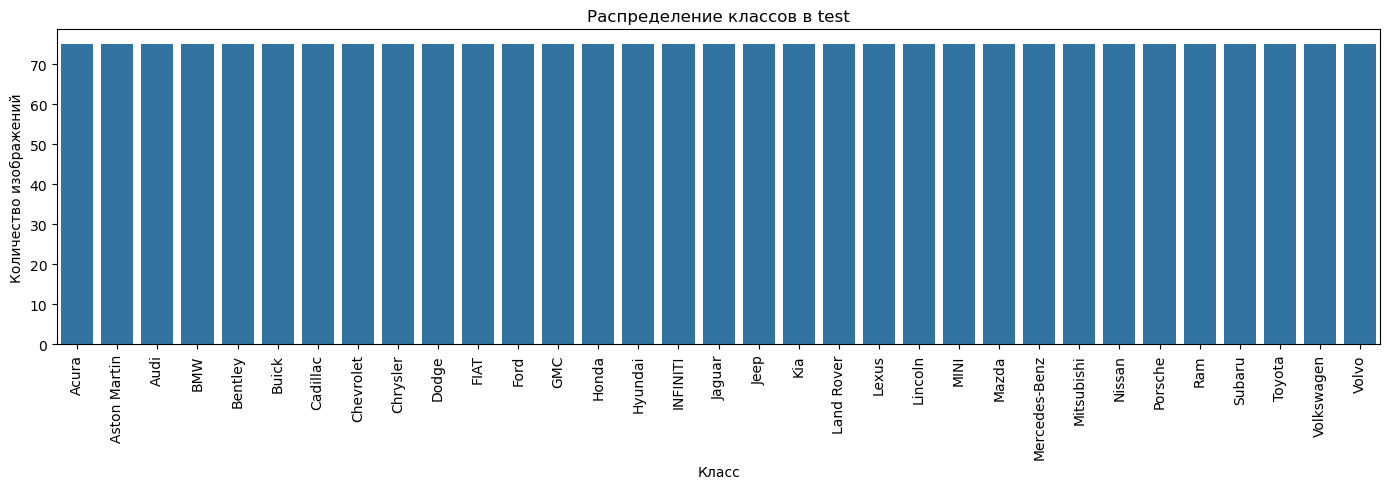

Коэффициент дисбаланса train max/min: 1.00


In [16]:
def plot_class_distribution(df: pd.DataFrame, title: str) -> None:
    counts = df["label"].value_counts().sort_values(ascending=False)
    plt.figure(figsize=(14, 5))
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(title)
    plt.xlabel("Класс")
    plt.ylabel("Количество изображений")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

plot_class_distribution(df_train, "Распределение классов в train")
plot_class_distribution(df_val, "Распределение классов в val")
plot_class_distribution(df_test, "Распределение классов в test")

class_counts = df_train["label_idx"].value_counts().sort_index()
imbalance_ratio = class_counts.max() / max(class_counts.min(), 1)
print(f"Коэффициент дисбаланса train max/min: {imbalance_ratio:.2f}")

## 3. `tf.data`-пайплайн и аугментация

Используется resize_with_pad, т.к. для авто критичны пропорции (resize) и нельзя обрезать (crop) - мы рискуем потерять важную часть изображения

Для baseline-модели используются изображения в диапазоне `[0, 1]`.

Для EfficientNet используется `preprocess_input`, совместимый с ImageNet-предобучением. Аугментация стала сильнее, но без чрезмерных искажений: марку машины нельзя менять агрессивными трансформациями.

In [17]:
def decode_image(path):
    """Читает изображение, приводит к RGB, float32 и нужному размеру."""
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize_with_pad(img, IMG_SIZE[0], IMG_SIZE[1])
    return img

augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
], name="augmenter")

def make_ds(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(min(len(paths), 4096), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(lambda x, y: (decode_image(x), y), num_parallel_calls=AUTO)
    ds = ds.cache()

    if augment:
        ds = ds.map(lambda x, y: (augmenter(x, training=True),y), num_parallel_calls=AUTO)

    ds = ds.map(lambda x, y: (preprocess_input(x * 255.0),y),num_parallel_calls=AUTO)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTO)

    return ds

train_ds = make_ds(
    df_train["path"].tolist(),
    df_train["label_idx"].tolist(),
    augment=True,
    shuffle=True,
)

val_ds = make_ds(
    df_val["path"].tolist(),
    df_val["label_idx"].tolist(),
)

test_ds = make_ds(
    df_test["path"].tolist(),
    df_test["label_idx"].tolist(),
)

print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float16, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## 4. Transfer learning: EfficientNetB0

По сравнению с исходным вариантом улучшены:

- classifier head: `Dense + BatchNorm + Dropout`;
- метрики top-3/top-5;
- `class_weight` для борьбы с дисбалансом;
- более аккуратный fine-tuning с меньшим learning rate;
- возможность размораживать backbone блоками.

Для дальнейших экспериментов можно заменить `EfficientNetB0` на `EfficientNetB2/B3`, `MobileNetV3Large`, `ResNet50V2`, `ConvNeXtTiny`.

In [25]:
search_space = [

    {
        "dropout": 0.25,
        "dense_units": 128,
        "lr": 3e-4,
    },

    {
        "dropout": 0.35,
        "dense_units": 256,
        "lr": 3e-4,
    },

    {
        "dropout": 0.40,
        "dense_units": 256,
        "lr": 1e-4,
    },

    {
        "dropout": 0.35,
        "dense_units": 512,
        "lr": 3e-4,
    },

    {
        "dropout": 0.4,
        "dense_units": 512,
        "lr": 3e-4,
    },
]

def build_model(dropout,dense_units,lr):
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,),
    )

    base_model.trainable = False

    inputs = layers.Input(shape=IMG_SIZE + (3,))

    x = base_model(inputs,training=False,
    )

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units,activation="relu",)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout * 0.75)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
    )(x)

    model = models.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),

        loss=tf.keras.losses.SparseCategoricalCrossentropy(),

        metrics=[
            "accuracy",

            tf.keras.metrics.SparseTopKCategoricalAccuracy(
                k=5,
                name="top5_acc",
            ),
        ],
    )

    return model

In [26]:
search_results = []

best_model = None
best_val_acc = 0.0

for i, config in enumerate(search_space):

    print("=" * 60)
    print(f"CONFIG {i+1}/{len(search_space)}")
    print(config)

    model_hp = build_model(
        dropout=config["dropout"],
        dense_units=config["dense_units"],
        lr=config["lr"],
    )

    history_hp = model_hp.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=1,
    )

    best_epoch_acc = max(
        history_hp.history["val_accuracy"]
    )

    search_results.append({
        **config,
        "val_accuracy": best_epoch_acc,
    })

    print(f"Best val_accuracy: {best_epoch_acc:.4f}")

    if best_epoch_acc > best_val_acc:
        best_val_acc = best_epoch_acc
        best_model = model_hp

print("\nBEST VAL ACC:", best_val_acc)

CONFIG 1/5
{'dropout': 0.25, 'dense_units': 128, 'lr': 0.0003}
Epoch 1/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 53s 112ms/step - accuracy: 0.0728 - loss: 3.7895 - top5_acc: 0.2574 - val_accuracy: 0.1123 - val_loss: 3.2468 - val_top5_acc: 0.3689
Epoch 2/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.1223 - loss: 3.3230 - top5_acc: 0.3664 - val_accuracy: 0.1487 - val_loss: 3.0924 - val_top5_acc: 0.4489
Epoch 3/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.1574 - loss: 3.1220 - top5_acc: 0.4301 - val_accuracy: 0.1677 - val_loss: 2.9795 - val_top5_acc: 0.4844
Epoch 4/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.1844 - loss: 2.9943 - top5_acc: 0.4661 - val_accuracy: 0.1947 - val_loss: 2.9073 - val_top5_acc: 0.5055
Epoch 5/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.2030 - loss: 2.9274 - top5_acc: 0.4938 - val_accuracy: 0.2061 - val_loss: 2.8633 - val_top5_acc: 0.5244
Best val_accuracy: 0.2061
CONFIG 2/5
{'dropout': 0.35, 'dense_units': 256, 'lr': 

In [27]:
results_hp_df = pd.DataFrame(
    search_results
)

results_hp_df = results_hp_df.sort_values(
    by="val_accuracy",
    ascending=False,
)

results_hp_df

,dropout,dense_units,lr,val_accuracy
3,0.35,512,0.0003,0.252525
4,0.40,512,0.0003,0.249697
1,0.35,256,0.0003,0.248081
0,0.25,128,0.0003,0.206061
2,0.40,256,0.0001,0.187879


In [29]:
best_config = results_hp_df.iloc[0]
best_config

dropout           0.350000
dense_units     512.000000
lr                0.000300
val_accuracy      0.252525
Name: 3, dtype: float64

In [35]:
def build_efficientnet(num_classes: int, img_size=IMG_SIZE, dropout=0.35, dense_units=512) -> tuple[tf.keras.Model, tf.keras.Model]:
    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(*img_size, 3),
    )
    base.trainable = False

    inputs = layers.Input(shape=(*img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout * 0.75)(x)

    logits = layers.Dense(num_classes)(x)
    outputs = layers.Activation("softmax", dtype="float32")(logits)

    model = models.Model(inputs, outputs, name="efficientnetb0_car_brand")
    return model, base

def compile_model(model: tf.keras.Model, lr: float) -> None:
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_accuracy"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy"),
        ],
    )

model_tl, base = build_efficientnet(num_classes)
compile_model(model_tl, lr=3e-4)
model_tl.summary()

Model: "efficientnetb0_car_brand"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 33)             │        16,929 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 33)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,724,420 (18.02 MB)

 Trainable params: 673,825 (2.57 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

In [38]:
tl_callbacks = [
    ModelCheckpoint(
        "models/effb0_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
    CSVLogger("models/effb0_training_log.csv", append=False),
]

print("Этап 1: обучение classifier head при замороженном backbone.")
hist_warmup = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_WARMUP,
    callbacks=tl_callbacks,
)

Этап 1: обучение classifier head при замороженном backbone.
Epoch 1/12
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.1092 - loss: 3.7962 - top3_accuracy: 0.2302 - top5_accuracy: 0.3207
Epoch 1: val_accuracy improved from None to 0.15879, saving model to models/effb0_best.keras

Epoch 1: finished saving model to models/effb0_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 43s 119ms/step - accuracy: 0.1299 - loss: 3.5766 - top3_accuracy: 0.2573 - top5_accuracy: 0.3508 - val_accuracy: 0.1588 - val_loss: 3.0793 - val_top3_accuracy: 0.3378 - val_top5_accuracy: 0.4586 - learning_rate: 3.0000e-04
Epoch 2/12
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1956 - loss: 3.0615 - top3_accuracy: 0.3649 - top5_accuracy: 0.4768
Epoch 2: val_accuracy improved from 0.15879 to 0.19111, saving model to models/effb0_best.keras

Epoch 2: finished saving model to models/effb0_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.2105 - loss: 3.0056 - top3_accuracy: 0.3820 - top5_acc

In [40]:
def set_fine_tuning(base_model: tf.keras.Model, fine_tune_layers: int) -> None:
    """Размораживает последние fine_tune_layers слоёв, кроме BatchNormalization."""
    base_model.trainable = True

    for layer in base_model.layers[:-fine_tune_layers]:
        layer.trainable = False

    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

FINE_TUNE_LAYERS = 80
set_fine_tuning(base, fine_tune_layers=FINE_TUNE_LAYERS)

trainable_count = sum(int(layer.trainable) for layer in base.layers)
print(f"Trainable слоёв backbone: {trainable_count} из {len(base.layers)}")

compile_model(model_tl, lr=3e-4)

print("Этап 2: fine-tuning верхних слоёв EfficientNetB0.")
hist_ft = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=tl_callbacks,
)

Trainable слоёв backbone: 63 из 238
Этап 2: fine-tuning верхних слоёв EfficientNetB0.
Epoch 1/24
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4549 - loss: 1.9881 - top3_accuracy: 0.6670 - top5_accuracy: 0.7591
Epoch 1: val_accuracy did not improve from 0.39596
360/360 ━━━━━━━━━━━━━━━━━━━━ 63s 123ms/step - accuracy: 0.4343 - loss: 2.0348 - top3_accuracy: 0.6510 - top5_accuracy: 0.7495 - val_accuracy: 0.3491 - val_loss: 2.5579 - val_top3_accuracy: 0.5612 - val_top5_accuracy: 0.6602 - learning_rate: 3.0000e-04
Epoch 2/24
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5208 - loss: 1.7063 - top3_accuracy: 0.7331 - top5_accuracy: 0.8186
Epoch 2: val_accuracy improved from 0.39596 to 0.41818, saving model to models/effb0_best.keras

Epoch 2: finished saving model to models/effb0_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.5308 - loss: 1.6628 - top3_accuracy: 0.7388 - top5_accuracy: 0.8254 - val_accuracy: 0.4182 - val_loss: 2.2076 - val_top3_accuracy

## 7. Графики обучения

Графики позволяют быстро увидеть:

- есть ли переобучение;
- достигла ли модель плато;
- помог ли fine-tuning после warmup;
- не слишком ли большой learning rate.

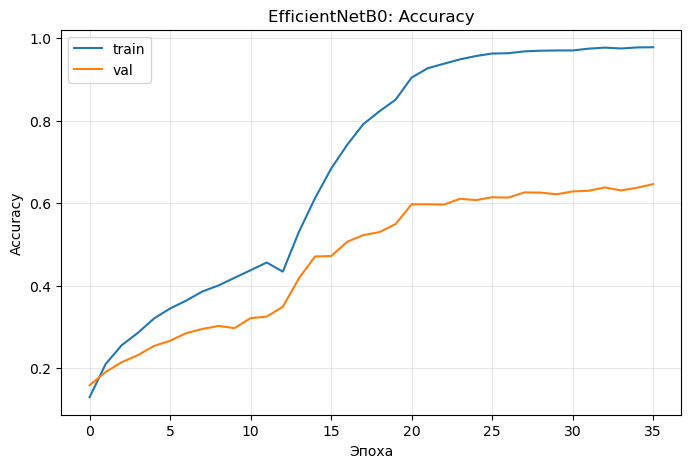

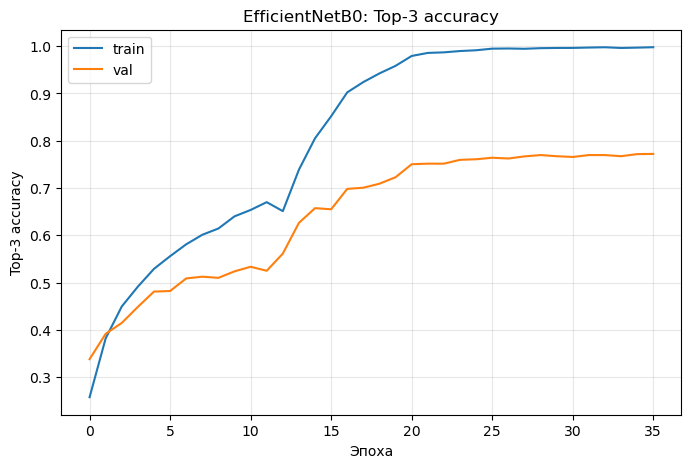

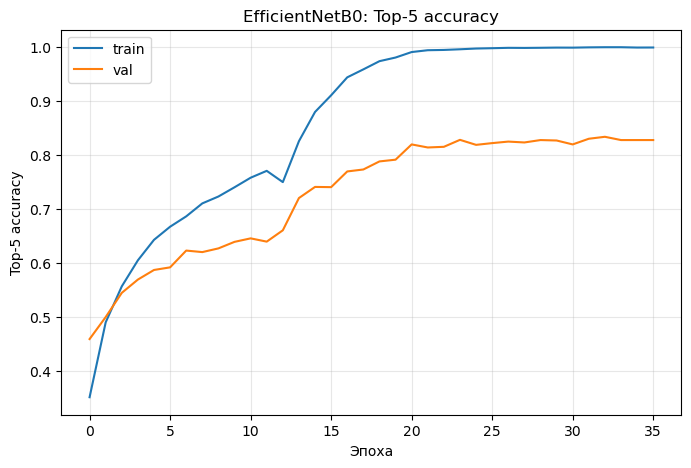

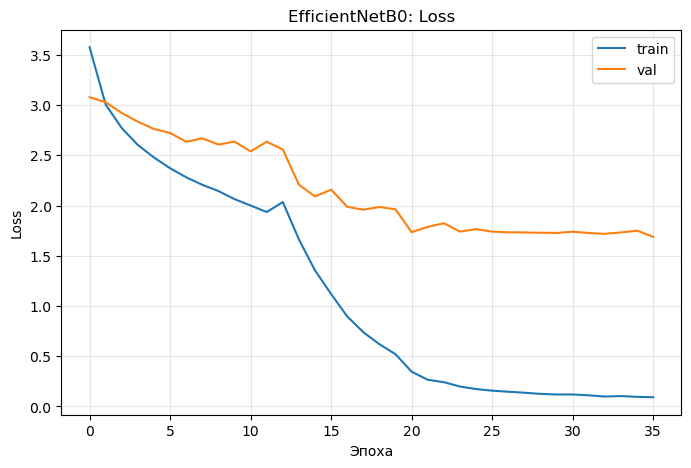

In [41]:
def merge_histories(*histories):
    merged = {}
    for history in histories:
        if history is None:
            continue
        for key, values in history.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

def plot_training_curves(history_dict, title="Обучение модели"):
    metrics = [
        ("accuracy", "val_accuracy", "Accuracy"),
        ("top3_accuracy", "val_top3_accuracy", "Top-3 accuracy"),
        ("top5_accuracy", "val_top5_accuracy", "Top-5 accuracy"),
        ("loss", "val_loss", "Loss"),
    ]

    for train_key, val_key, metric_name in metrics:
        if train_key not in history_dict or val_key not in history_dict:
            continue

        plt.figure(figsize=(8, 5))
        plt.plot(history_dict[train_key], label="train")
        plt.plot(history_dict[val_key], label="val")
        plt.title(f"{title}: {metric_name}")
        plt.xlabel("Эпоха")
        plt.ylabel(metric_name)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

history_all = merge_histories(hist_warmup, hist_ft)
plot_training_curves(history_all, title="EfficientNetB0")

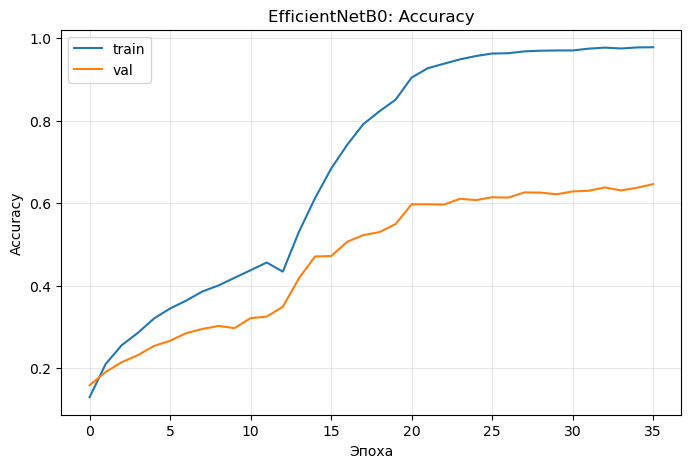

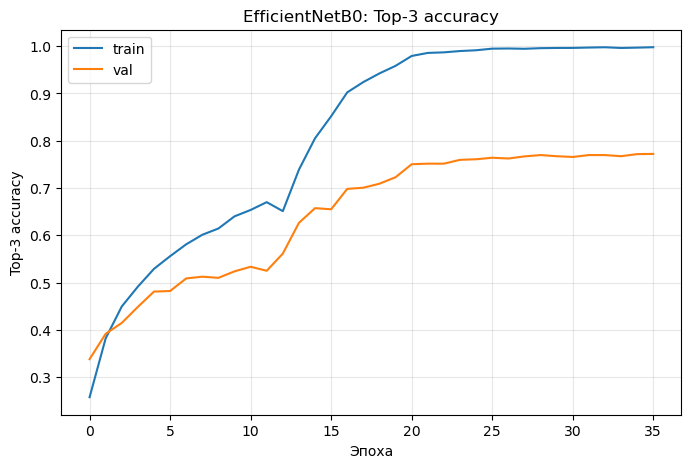

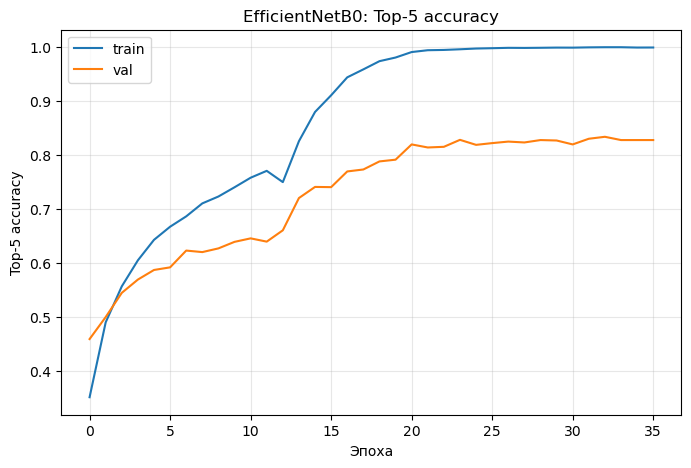

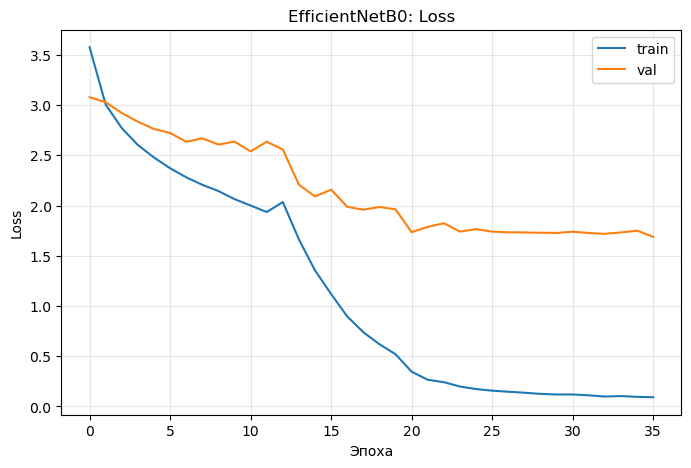

In [42]:
def merge_histories(*histories):
    merged = {}
    for history in histories:
        if history is None:
            continue
        for key, values in history.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

def plot_training_curves(history_dict, title="Обучение модели"):
    metrics = [
        ("accuracy", "val_accuracy", "Accuracy"),
        ("top3_accuracy", "val_top3_accuracy", "Top-3 accuracy"),
        ("top5_accuracy", "val_top5_accuracy", "Top-5 accuracy"),
        ("loss", "val_loss", "Loss"),
    ]

    for train_key, val_key, metric_name in metrics:
        if train_key not in history_dict or val_key not in history_dict:
            continue

        plt.figure(figsize=(8, 5))
        plt.plot(history_dict[train_key], label="train")
        plt.plot(history_dict[val_key], label="val")
        plt.title(f"{title}: {metric_name}")
        plt.xlabel("Эпоха")
        plt.ylabel(metric_name)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

history_all = merge_histories(hist_warmup, hist_ft)
plot_training_curves(history_all, title="EfficientNetB0")

## 8. Оценка на test и подробные метрики

Обычная accuracy не всегда достаточно информативна. Для 33 классов полезны:

- `top-3 accuracy`: правильная марка попала в 3 наиболее вероятных варианта;
- `top-5 accuracy`: правильная марка попала в 5 вариантов;
- precision/recall/F1 по каждому классу;
- confusion matrix.

In [44]:
best_tl_path = "models/effb0_best.keras"

if os.path.exists(best_tl_path):
    model_tl.load_weights(best_tl_path)
    print("Загружены лучшие веса:", best_tl_path)
else:
    print("Лучший checkpoint не найден, используются текущие веса модели.")

test_metrics = model_tl.evaluate(test_ds, verbose=0)
print("Метрики EfficientNetB0 на test:")
for name, value in zip(model_tl.metrics_names, test_metrics):
    print(f"{name}: {value:.4f}")

y_true = df_test["label_idx"].values
y_pred_proba = model_tl.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nПроверка top-k через sklearn:")
print("Top-3 accuracy:", top_k_accuracy_score(y_true, y_pred_proba, k=3, labels=np.arange(num_classes)))
print("Top-5 accuracy:", top_k_accuracy_score(y_true, y_pred_proba, k=5, labels=np.arange(num_classes)))

report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4,
    zero_division=0,
    output_dict=True,
)
report_df = pd.DataFrame(report).T
display(report_df)

Загружены лучшие веса: models/effb0_best.keras
Метрики EfficientNetB0 на test:
loss: 1.6869
compile_metrics: 0.6331
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 90ms/step

Проверка top-k через sklearn:
Top-3 accuracy: 0.7749494949494949
Top-5 accuracy: 0.8298989898989899


,precision,recall,f1-score,support
Acura,0.709677,0.586667,0.642336,75.000000
Aston Martin,0.813333,0.813333,0.813333,75.000000
Audi,0.718310,0.680000,0.698630,75.000000
BMW,0.600000,0.440000,0.507692,75.000000
Bentley,0.738462,0.640000,0.685714,75.000000
Buick,0.694444,0.666667,0.680272,75.000000
Cadillac,0.781250,0.666667,0.719424,75.000000
Chevrolet,0.723404,0.453333,0.557377,75.000000
Chrysler,0.717391,0.880000,0.790419,75.000000
Dodge,0.641791,0.573333,0.605634,75.000000


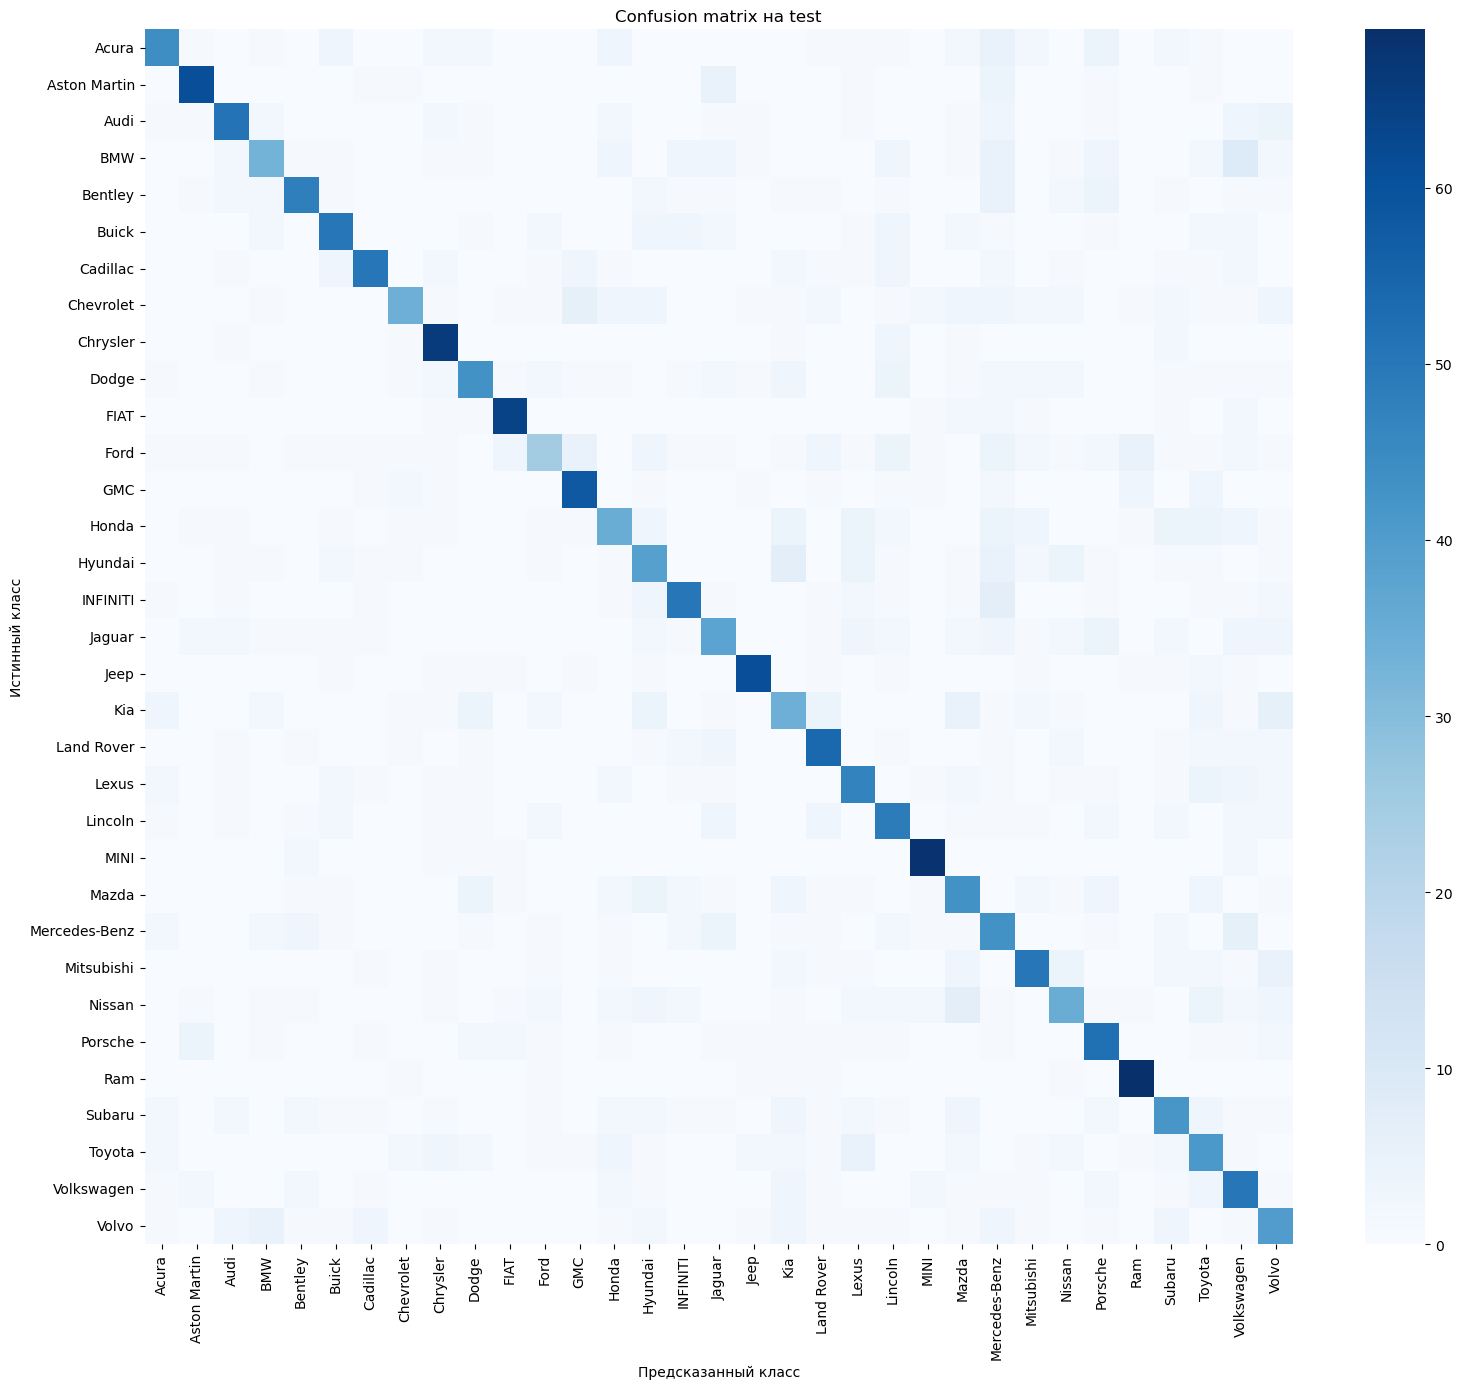

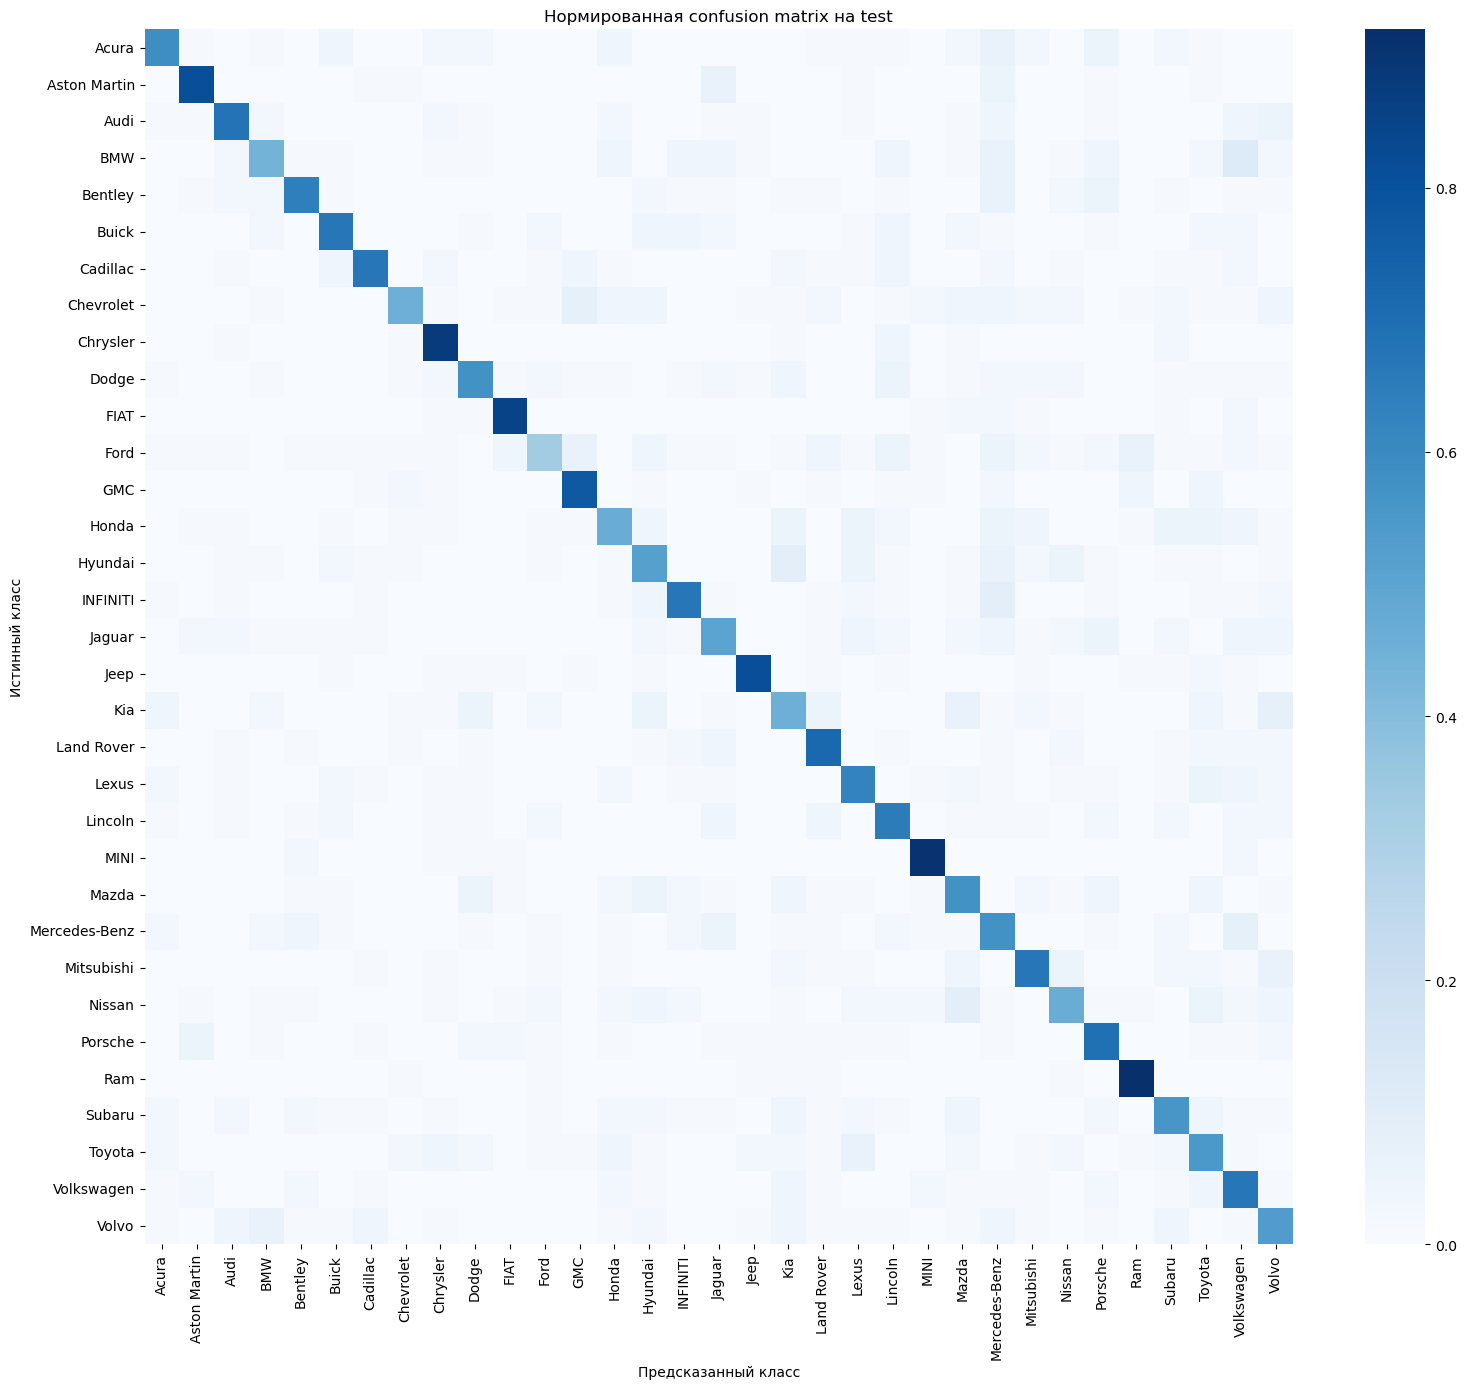

In [45]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    square=False,
    cbar=True,
)
plt.title("Confusion matrix на test")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Нормированная матрица показывает доли ошибок внутри каждого истинного класса.
cm_norm = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    square=False,
    cbar=True,
)
plt.title("Нормированная confusion matrix на test")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
# Таблица самых частых пар ошибок.
error_pairs = []
for true_idx in range(num_classes):
    for pred_idx in range(num_classes):
        if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
            error_pairs.append({
                "true_class": idx2class[true_idx],
                "pred_class": idx2class[pred_idx],
                "count": int(cm[true_idx, pred_idx]),
                "share_within_true_class": float(cm_norm[true_idx, pred_idx]),
            })

error_pairs_df = pd.DataFrame(error_pairs).sort_values(
    ["count", "share_within_true_class"],
    ascending=False,
)
display(error_pairs_df.head(30))

,true_class,pred_class,count,share_within_true_class
51,BMW,Volkswagen,9,0.120000
216,Hyundai,Kia,7,0.093333
237,INFINITI,Mercedes-Benz,7,0.093333
403,Nissan,Mazda,7,0.093333
101,Chevrolet,GMC,6,0.080000
289,Kia,Volvo,6,0.080000
376,Mercedes-Benz,Volkswagen,6,0.080000
10,Acura,Mercedes-Benz,5,0.066667
17,Aston Martin,Jaguar,5,0.066667
47,BMW,Mercedes-Benz,5,0.066667


## 9. Анализ ошибочных предсказаний

Ниже выводятся изображения, где модель ошиблась сильнее всего. Это помогает понять источник проблемы:

- визуально похожие марки;
- неправильные labels;
- слишком маленький или закрытый логотип;
- плохое качество изображения;
- доменный сдвиг между train и test.

1358. true=Kia, pred=Volvo, top5=[Volvo: 1.00, Kia: 0.00, Ford: 0.00, INFINITI: 0.00, Buick: 0.00], path=/home/sm/Desktop/ml/CarBrandClassificationDataset/test/Kia/Kia_Telluride_2020_39_18_290_38_6_78_69_196_19_AWD_8_4_SUV_vga.jpg
1161. true=INFINITI, pred=Mercedes-Benz, top5=[Mercedes-Benz: 1.00, Lexus: 0.00, Bentley: 0.00, Toyota: 0.00, Ford: 0.00], path=/home/sm/Desktop/ml/CarBrandClassificationDataset/test/INFINITI/INFINITI_Q60_2014_48_18_320_37_6_72_55_183_18_RWD_4_2_Convertible_AjV.jpg
1386. true=Kia, pred=Volvo, top5=[Volvo: 1.00, Lincoln: 0.00, Land Rover: 0.00, Bentley: 0.00, Cadillac: 0.00], path=/home/sm/Desktop/ml/CarBrandClassificationDataset/test/Kia/Kia_Sorento_2013_23_17_170_24_4_74_67_183_21_FWD_5_4_SUV_MBu.jpg
727. true=Dodge, pred=Volkswagen, top5=[Volkswagen: 1.00, Dodge: 0.00, FIAT: 0.00, Kia: 0.00, Jeep: 0.00], path=/home/sm/Desktop/ml/CarBrandClassificationDataset/test/Dodge/Dodge_Challenger_2017_37_20_480_64_8_75_57_197_14_RWD_5_2_2dr_jJg.jpg
1892. true=Mitsubis

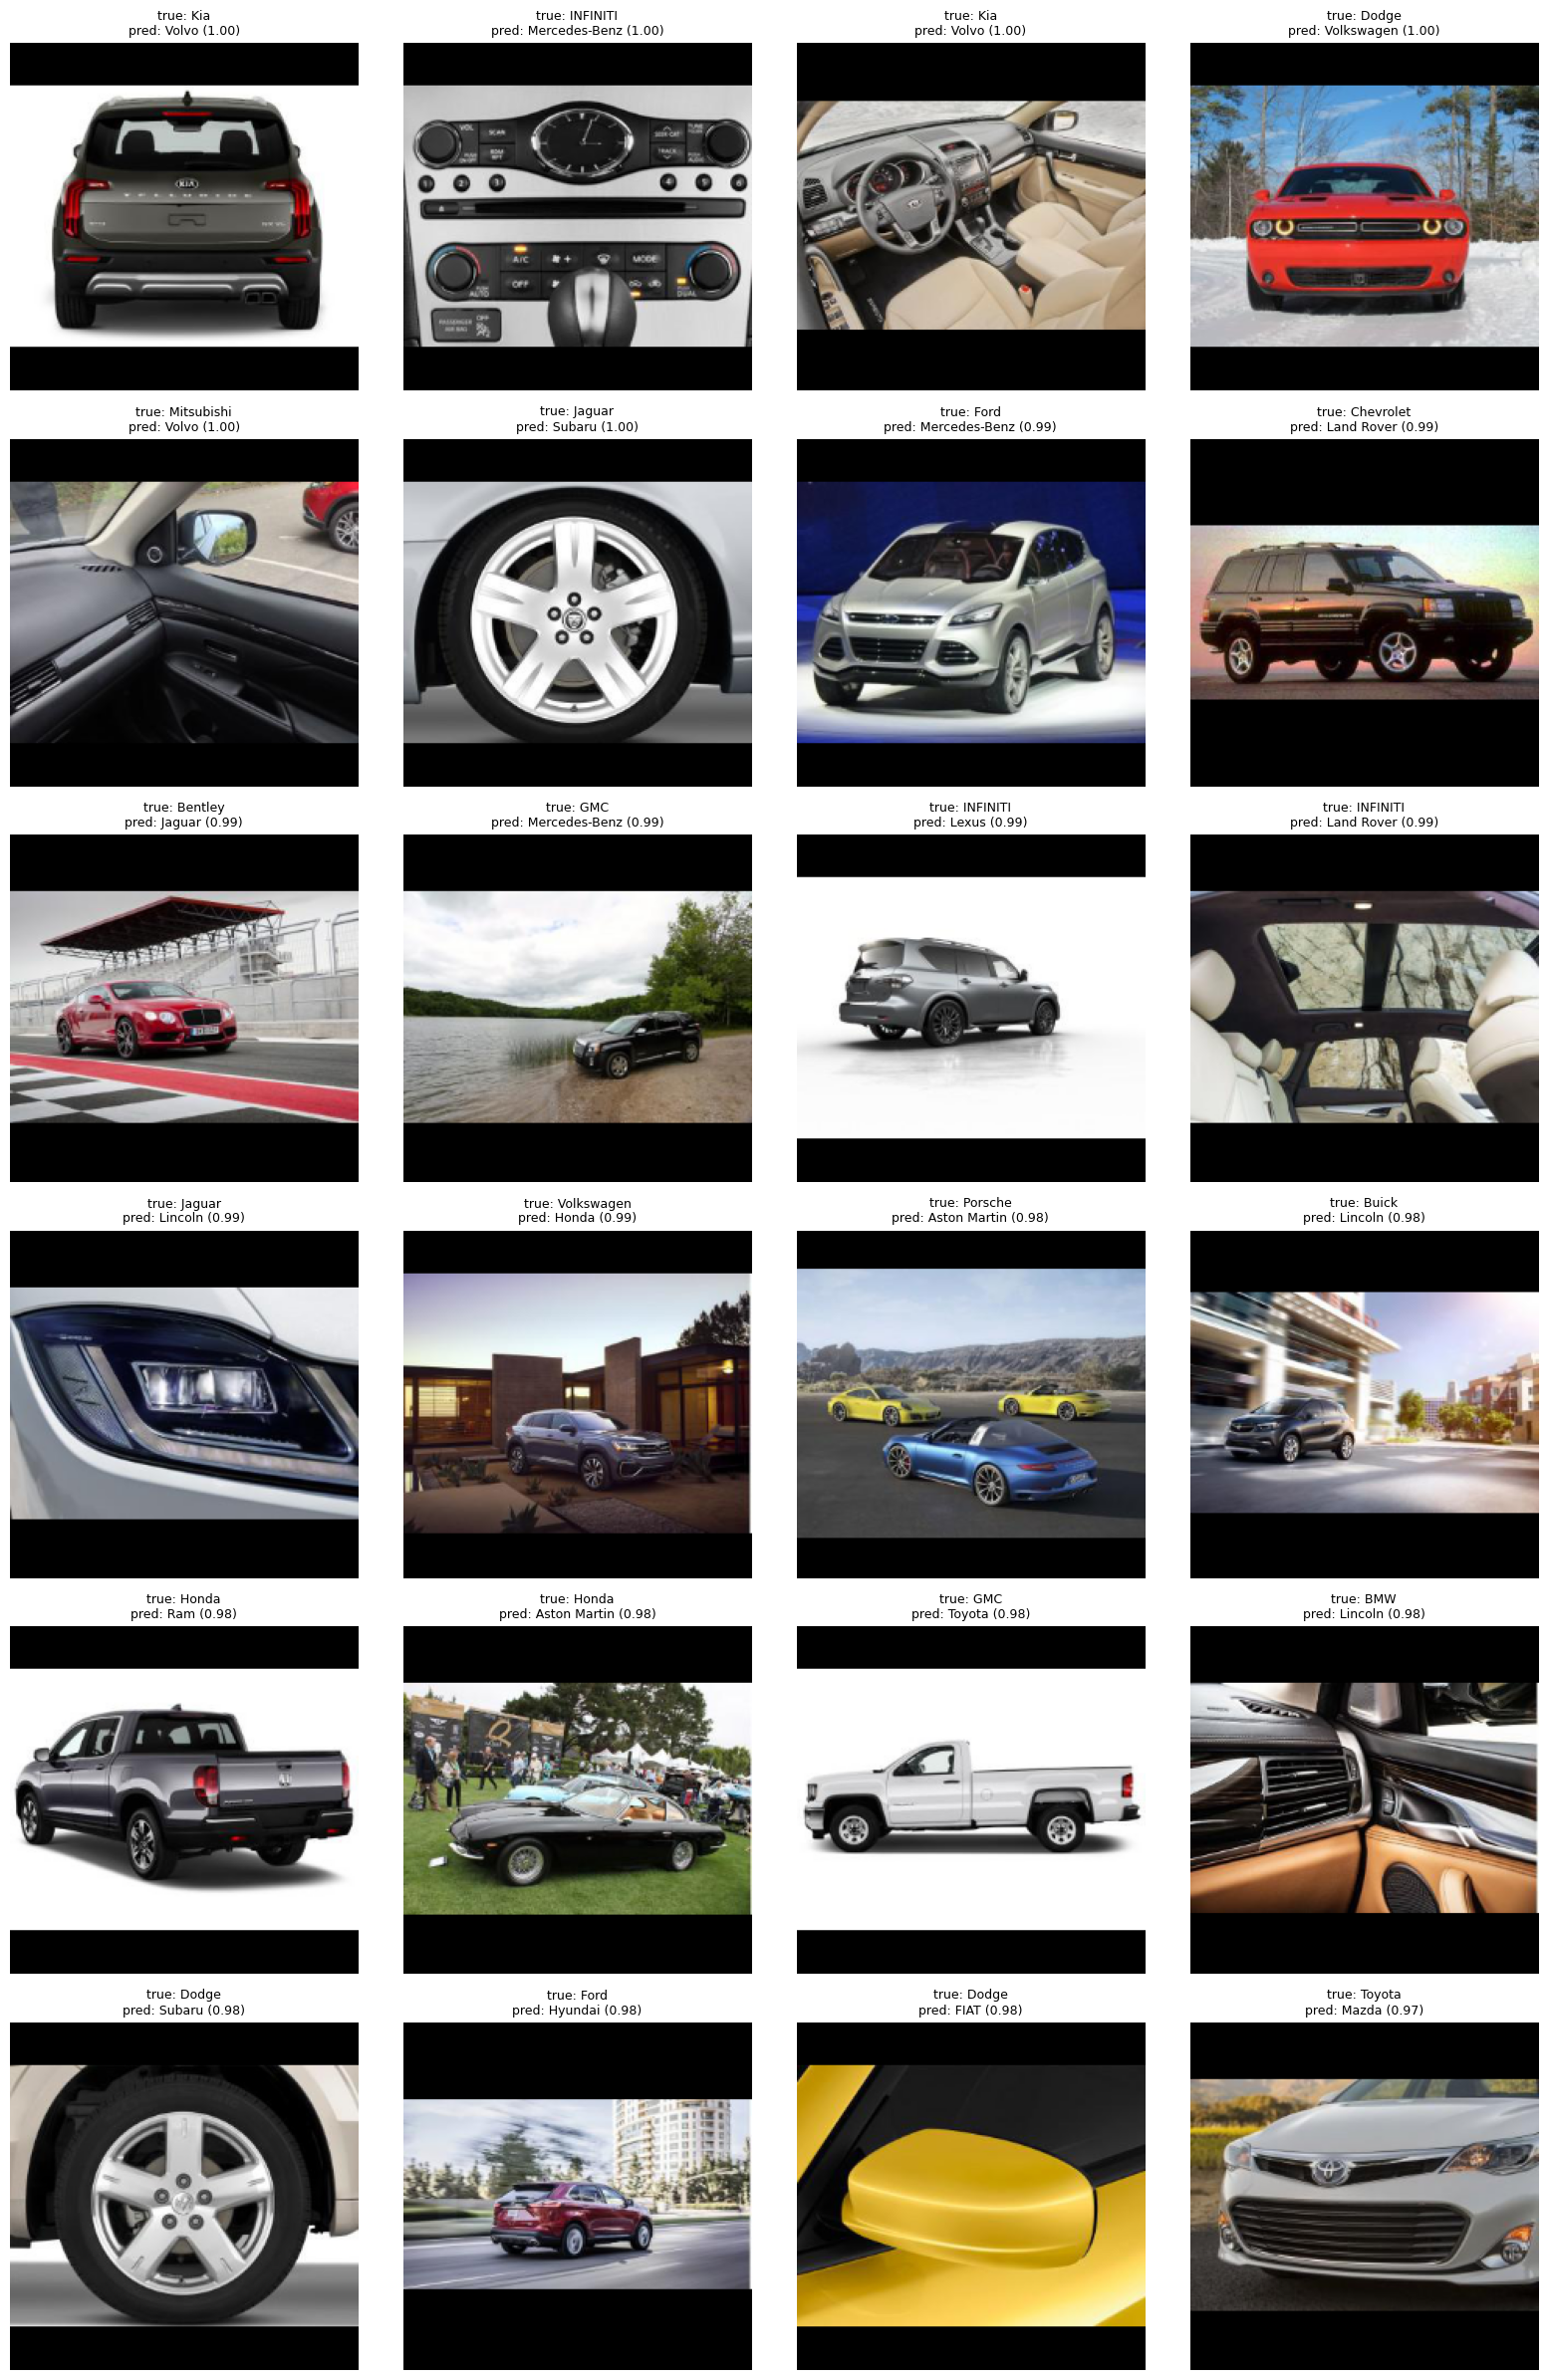

In [47]:
def show_misclassified_examples(df, y_true, y_pred, y_pred_proba, n=24):
    wrong_idx = np.where(y_true != y_pred)[0]
    if len(wrong_idx) == 0:
        print("Ошибок не найдено.")
        return

    # Уверенность модели в ошибочном предсказании.
    wrong_conf = y_pred_proba[wrong_idx, y_pred[wrong_idx]]
    order = wrong_idx[np.argsort(-wrong_conf)]
    selected = order[:n]

    cols = 4
    rows = int(np.ceil(len(selected) / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, idx in enumerate(selected, start=1):
        img = decode_image(df.iloc[idx]["path"]).numpy()

        true_name = idx2class[int(y_true[idx])]
        pred_name = idx2class[int(y_pred[idx])]
        conf = float(y_pred_proba[idx, y_pred[idx]])

        top5 = np.argsort(-y_pred_proba[idx])[:5]
        top5_text = ", ".join([f"{idx2class[int(j)]}: {y_pred_proba[idx, j]:.2f}" for j in top5])

        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"true: {true_name}\npred: {pred_name} ({conf:.2f})", fontsize=9)
        print(f"{idx}. true={true_name}, pred={pred_name}, top5=[{top5_text}], path={df.iloc[idx]['path']}")

    plt.tight_layout()
    plt.show()

show_misclassified_examples(df_test, y_true, y_pred, y_pred_proba, n=24)